# PVQ


In [ ]:
import ast
from collections import Counter,defaultdict
import pandas as pd
import json
import re


models = ["4o","gemini","claude","grok","llama","qwen","dpsk","kimi","seed","glm"]#

all_results = {prompt_idx: {} for prompt_idx in range(5)}
adjusted_results = {prompt_idx: {} for prompt_idx in range(5)}
for model in models:
    print(f"{model}\n\n\n\n\n")
    with open(f"./result/{model}_result_exp_pvq.txt", "r", encoding="utf-8") as file:
        lines = [line.strip() for line in file.readlines()]

    value_scores_list = [defaultdict(int) for _ in range(5)]
    value_avg_list = [defaultdict(int) for _ in range(5)]

    # In the PVQ section, each response is stored in 12 lines.
    # Line 1 indicates the trial number.
    # Lines 2–11 list the human values and their corresponding statements,
    # along with the shuffled indices and contents.
    # Line 12 contains the model's outputs for the five prompts.
    for idx in range(0, len(lines), 12):
      position_mapping={}
      # handle shuffled pvq
      block = lines[idx:idx+12]
      if len(block) < 12:
          continue
      for i in range(10):
        pair = block[1+i]
        value, raw_list_str = pair.split(":", 1)
        value = value.strip()
        parsed = ast.literal_eval(raw_list_str.strip())
        position_mapping[value]=parsed


      #handle model responses
      model_choices = []
      model_choices_raw = ast.literal_eval(block[11].split(f"model_choice:")[1].strip())
      for model_choice_raw in model_choices_raw:
        model_choice = re.search(r'({.*?})', model_choice_raw, re.DOTALL)
        if model_choice:
          try:
            parsed = json.loads(model_choice.group(1))
            model_choices.append(parsed)
          except:
            print(model_choice_raw)
        else:
          print(model_choice_raw)
      #print(model_choices)

      # calculate avg
      value_scores_by_trial = [defaultdict(int) for _ in range(5)]
      overall_avg_by_trial = []
      for i, model_choice in enumerate(model_choices):
        for value, statements in position_mapping.items():
          for stmt_number, _ in statements:
            try:
              score_str = model_choice.get(str(stmt_number))
            except:
              continue
            if score_str is not None:
              score = int(score_str)
              value_scores_list[i][value] += score
              value_scores_by_trial[i][value] += score

      for i, model_choice in enumerate(model_choices):
        overall_avg_by_trial.append(round(sum(value_scores_by_trial[i].values())/40,2))


      for i, model_choice in enumerate(model_choices):
        for value, statements in position_mapping.items():
          stmt_count=len(statements)
          value_scores_by_trial[i][value] = round(value_scores_by_trial[i][value]/stmt_count, 2)
          #print(f"{value}: {value_scores_by_trial[i][value]}")
          value_avg_list[i][value] += value_scores_by_trial[i][value] - overall_avg_by_trial[i]

    for i in range(5):
      for value in position_mapping.keys():
        value_avg_list[i][value] = round(value_avg_list[i][value]/10, 2)


    for value, statements in position_mapping.items():
      stmt_count=len(statements)*10  # shuffle ten times in total
      for i in range(len(value_scores_list)):
        if value not in all_results[i]:
            all_results[i][value] = {}
            adjusted_results[i][value] = {}
        all_results[i][value][model] = round(value_scores_list[i][value]/stmt_count, 2)
        #adjusted_results[i][value][model] = value_avg_list[i][value]


print(all_results)

for p_idx in range(5):
    df = pd.DataFrame.from_dict(all_results[p_idx], orient="index")
    df.index.name = "Attribute"
    df.columns.name = "Model"

    desired_order = [
        "Universalism", "Benevolence", "Tradition", "Conformity",
        "Security", "Power", "Achievement", "Hedonism",
        "Stimulation", "Self-direction"
    ]

    df = df.reindex(desired_order)

    path = f"pvq_adjusted_prompt{p_idx+1}.xlsx"
    df.to_excel(path)
    print(f"Results of prompt {p_idx+1} are saved to: {path}")


#default

##Accuracy by Values

In [ ]:
import ast
from collections import Counter
import pandas as pd
import json
import re


models = ["4o","gemini","claude","grok","llama","qwen","dpsk","kimi","seed","glm"]

all_results = {prompt_idx: {} for prompt_idx in range(5)}

for model in models:
    print(f"{model}\n\n\n\n\n")
    scenario_idx=0
    with open(f"./result/{model}_result_exp_default_reddit.txt", "r", encoding="utf-8") as file:
        lines = [line.strip() for line in file.readlines()]

    attribute_counter_list = [Counter() for _ in range(5)]
    correct_counter_list = [Counter() for _ in range(5)]

    # Each block contains 7 lines. You may modify this structure as needed,
    # but you must also update the result-saving logic accordingly.
    # Line 1 corresponds to the scenario content and is hidden for copyright and privacy reasons.
    # Line 2 records the order and content of actions for the five prompts.
    # Lines 3–7 contain the model outputs for the five prompts.
    for idx in range(0, len(lines), 7):
      scenario_idx+=1
      block = lines[idx:idx+7]
      if len(block) < 7:
          continue
      scenario=block[0]
      questions = ast.literal_eval(block[1])
      # five prompts
      model_choices = [[] for _ in range(5)]
      for id in range(5):
        try:
          model_choices_raw = ast.literal_eval(block[2+id].split(f"model_choice for prompt{id+1}:")[1].strip())
        except:
          print(block[2+id])
          break
        for model_choice_raw in model_choices_raw:
          pattern = re.compile(
              r'"Answer":\s*"?([A-Z])"?'
              r'|The best answer is\s*([A-Z])',
              re.IGNORECASE
          )
          model_choice = pattern.search(model_choice_raw)

          #model_choice = re.search(r'"Answer":\s*"(.*?)"', model_choice_raw)
          if model_choice:
            try:
              model_choices[id].append((model_choice.group(1) or model_choice.group(2))[0])
            except:
              print("Not a valid choice："+model_choice.group(1))
              model_choices[id].append("X")
          else:
            model_choices[id].append("X")
            if model == "seed":
              print(scenario)
            print("Not answer:" + model_choice_raw)

      for p_idx in range(5):
        for i, m in enumerate(model_choices[p_idx]):
          j = ord(m) - ord('A')
          if j>=4:  # not a valid choice
            continue
          value = questions[i][j][1]
          attribute_counter_list[p_idx][value] += 1


    for p_idx in range(5):
      print(f"prompt{p_idx+1}")
      total = attribute_counter_list[p_idx].total()
      print(f"total: {total}")
      for value in attribute_counter_list[p_idx]:
        count = attribute_counter_list[p_idx][value]
        print(value+":"+str(count))
        if value not in all_results[p_idx]:
            all_results[p_idx][value] = {}
        all_results[p_idx][value][model] = round((count/total)*100, 2)
      print("\n\n")

    print(scenario_idx)
for p_idx in range(5):
    df = pd.DataFrame.from_dict(all_results[p_idx], orient="index")
    df.index.name = "Attribute"
    df.columns.name = "Model"

    # change Attribute order
    desired_order = [
        "Universalism", "Benevolence", "Tradition", "Conformity",
        "Security", "Power", "Achievement", "Hedonism",
        "Stimulation", "Self-direction"
    ]
    df = df.reindex(desired_order)

    path = f"default_prompt{p_idx+1}_reddit.xlsx"
    df.to_excel(path)
    print(f"Results of prompt {p_idx+1} are saved to: {path}")


##Accuracy by Categories

In [ ]:
import ast
from collections import Counter
import pandas as pd
import json
import re

models = ["4o", "qwen", "gemini","dpsk"]#

all_results = {prompt_idx: {} for prompt_idx in range(5)}

category_names = ["Career & work", "Financial & investment", "Education & academy", "Relationships", "Ethics"]

for model in models:
    print(f"{model}\n\n\n\n\n")
    scenario_idx = 0
    with open(f"./result/{model}_result_exp_default_reddit.txt", "r", encoding="utf-8") as file:
        lines = [line.strip() for line in file.readlines()]

    total_per_category_prompt = [[0 for _ in range(6)] for _ in range(5)]  # prompt_idx x category_idx
    correct_per_category_prompt = [[0 for _ in range(6)] for _ in range(5)]


    # Each block contains 7 lines. You may modify this structure as needed,
    # but you must also update the result-saving logic accordingly.
    # Line 1 corresponds to the scenario content and is hidden for copyright and privacy reasons.
    # Line 2 records the order and content of actions for the five prompts.
    # Lines 3–7 contain the model outputs for the five prompts.
    for idx in range(0, len(lines), 7):
        scenario_idx += 1
        block = lines[idx:idx+7]
        if len(block) < 7:
            continue

        questions = ast.literal_eval(block[1])
        model_choices = [[] for _ in range(5)]
        for id in range(5):
            try:
                model_choices_raw = ast.literal_eval(block[2+id].split(f"model_choice for prompt{id+1}:")[1].strip())
            except:
                print(block[2+id])
                break
            for model_choice_raw in model_choices_raw:
                model_choice = re.search(r'"Answer":\s*"(.*?)"', model_choice_raw)
                if model_choice:
                    try:
                        model_choices[id].append(model_choice.group(1)[0])
                    except:
                        print("Not a valid choice："+model_choice.group(1))
                        model_choices[id].append("X")
                else:
                    model_choices[id].append("X")
                    print("Not answer:" + model_choice_raw)

        category_idx = (scenario_idx - 1) // 600
        if category_idx >= 6:
            category_idx = 5

        for p_idx in range(5):
            for i, m in enumerate(model_choices[p_idx]):
                j = ord(m) - ord('A')
                total_per_category_prompt[p_idx][category_idx] += 1
                try:
                    correct_answer_index = questions[i][-1]
                    if j == correct_answer_index:
                        correct_per_category_prompt[p_idx][category_idx] += 1
                except:
                    continue

    for p_idx in range(5):
        print(f"prompt{p_idx+1}")
        for cat_idx, cat_name in enumerate(category_names):
            total = total_per_category_prompt[p_idx][cat_idx]
            correct = correct_per_category_prompt[p_idx][cat_idx]
            acc = round((correct / total) * 100, 2) if total > 0 else 0.0
            print(f"{cat_name}: {acc}% ({correct}/{total})")

            if cat_name not in all_results[p_idx]:
                all_results[p_idx][cat_name] = {}
            all_results[p_idx][cat_name][model] = acc
        print("\n\n")

print(scenario_idx)
for p_idx in range(5):
    df = pd.DataFrame.from_dict(all_results[p_idx], orient="index")
    df.index.name = "Category"
    df.columns.name = "Model"

    df = df.reindex(category_names)

    path = f"default_prompt{p_idx+1}_reddit_accuracy_by_category.xlsx"
    df.to_excel(path)
    print(f"Results of prompt {p_idx+1} are saved to: {path}")


## Tempreture Sensitivity

In [ ]:
import ast
from collections import Counter
import pandas as pd
import json
import re

models = ["4o", "gemini", "qwen", "dpsk"]
tempretures = ["0.5", "1"]

all_results = {
    temp: {prompt_idx: {} for prompt_idx in range(5)}
    for temp in tempretures
}

for model in models:
    for tempreture in tempretures:
        print(f"{model}  temp={tempreture}\n\n\n\n\n")
        scenario_idx = 0

        with open(f"./result/{model}_result_exp_default_reddit_temp{tempreture}.txt",
                  "r", encoding="utf-8") as file:
            lines = [line.strip() for line in file.readlines()]

        attribute_counter_list = [Counter() for _ in range(5)]
        correct_counter_list = [Counter() for _ in range(5)]

        # Each block contains 3 lines. You may modify this structure as needed,
        # but you must also update the result-saving logic accordingly.
        # Line 1 corresponds to the scenario content and is hidden for copyright and privacy reasons.
        # Line 2 records the order and content of actions for the five prompts.
        # Lines 3 contain the model outputs.
        for idx in range(0, len(lines), 3):
            scenario_idx += 1
            block = lines[idx:idx + 3]
            if len(block) < 3:
                continue

            scenario = block[0]

            questions = ast.literal_eval(block[1])
            model_choices = [[] for _ in range(1)]

            # model choice
            for id in range(1):
                try:
                    model_choices_raw = ast.literal_eval(
                        block[2 + id].split(f"model_choice for prompt{id + 1}:")[1].strip()
                    )
                except:
                    print(block[2 + id])
                    break

                for model_choice_raw in model_choices_raw:
                    pattern = re.compile(
                        r'"Answer":\s*"?([A-Z])"?'
                        r'|The best answer is\s*([A-Z])',
                        re.IGNORECASE
                    )
                    match = pattern.search(model_choice_raw)

                    if match:
                        answer = (match.group(1) or match.group(2))[0]
                        model_choices[id].append(answer)
                    else:
                        model_choices[id].append("X")
                        print("Not answer: " + model_choice_raw)

            for p_idx in range(1):
                for i, m in enumerate(model_choices[p_idx]):
                    j = ord(m) - ord('A')
                    if j >= 4:  # invalid
                        continue
                    value = questions[i][j][1]
                    attribute_counter_list[p_idx][value] += 1

        for p_idx in range(1):
            print(f"prompt{p_idx + 1}")
            total = attribute_counter_list[p_idx].total()
            print(f"total: {total}")

            for value in attribute_counter_list[p_idx]:
                count = attribute_counter_list[p_idx][value]
                print(value + ":" + str(count))

                if value not in all_results[tempreture][p_idx]:
                    all_results[tempreture][p_idx][value] = {}

                all_results[tempreture][p_idx][value][model] = round((count / total) * 100, 2)

            print("\n\n")

        print(scenario_idx)

for tempreture in tempretures:
    for p_idx in range(1):
        df = pd.DataFrame.from_dict(all_results[tempreture][p_idx], orient="index")
        df.index.name = "Attribute"
        df.columns.name = "Model"

        desired_order = [
            "Universalism", "Benevolence", "Tradition", "Conformity",
            "Security", "Power", "Achievement", "Hedonism",
            "Stimulation", "Self-direction"
        ]
        df = df.reindex(desired_order)

        output_path = f"default_prompt_reddit_temp{tempreture}.xlsx"
        df.to_excel(output_path)
        print(f"Save the result of temperature={tempreture} to:{output_path}")


# PCA

In [ ]:
import ast
from collections import Counter, defaultdict
import pandas as pd
import re

models = ["4o","gemini","claude","grok","llama","qwen","dpsk","kimi","seed","glm"]
category_names = ["Career & work", "Financial & investment", "Education & academy", "Relationships", "Ethics"]
value_names = [
    "Self-direction", "Tradition", "Hedonism", "Security", "Achievement",
    "Stimulation", "Conformity", "Universalism", "Benevolence", "Power"
]

random_indices=[259, 2206, 496, 1115, 8, 1629, 2079, 1860, 1923, 861, 83, 2936, 1662, 2674, 2224, 2059, 1784, 2137, 968, 856, 1167, 2303, 964, 678, 2039, 2876, 1316, 2532, 1679, 1775, 512, 273, 2141, 2041, 2199, 463, 2586, 55, 812, 2016, 2889, 1192, 1949, 790, 2952, 1726, 1415, 876, 758, 2863, 2109, 546, 2879, 36, 97, 2313, 1017, 1915, 2956, 70, 2358, 1731, 2665, 2518, 2108, 1616, 722, 1749, 1639, 1127, 2517, 2614, 1948, 899, 2424, 1332, 2815, 195, 2500, 2903, 1143, 1463, 771, 713, 1243, 1632, 2911, 1780, 561, 1152, 824, 1666, 2352, 581, 1855, 500, 1510, 1471, 1688, 1648, 2263, 636, 105, 1651, 2540, 2645, 1483, 2756, 1903, 2888, 2350, 151, 1772, 2202, 2695, 298, 2381, 1386, 2020, 1368, 2254, 89, 1600, 699, 789, 2590, 661, 1968, 1558, 1435, 1456, 1518, 2400, 101, 752, 2976, 537, 2201, 2880, 250, 1023, 715, 207, 1580, 1213, 854, 1927, 316, 2675, 946, 2983, 2220, 329, 1322, 175, 1474, 446, 1349, 300, 325, 2514, 2873, 220, 1718, 2851, 2373, 1197, 1135, 1547, 2402, 93, 2232, 454, 1919, 1768, 2361, 974, 1951, 2637, 518, 285, 2032, 1943, 301, 784, 712, 2628, 1284, 1343, 891, 903, 47, 835, 108, 2174, 786, 2739, 2204, 2460, 241, 1876, 2647, 1314, 1497, 2423, 1048, 2182, 23, 423, 1034, 1624, 2066, 2047, 1677, 2365, 71, 927, 1956, 664, 2883, 1046, 565, 716, 1517, 1060, 436, 2357, 855, 938, 2172, 894, 2485, 507, 1412, 954, 2651, 2692, 1393, 2292, 2329, 2029, 202, 1697, 102, 2389, 1926, 1541, 1462, 1158, 2827, 1255, 756, 164, 1519, 921, 2102, 1226, 2398, 711, 1714, 967, 1287, 2080, 1813, 337, 1820, 379, 1427, 213, 2997, 1396, 437, 1584, 1238, 896, 1545, 2349, 2422, 2143, 667, 674, 1353, 913, 1117, 60, 2542, 2826, 1035, 1378, 315, 857, 335, 65, 404, 214, 312, 1707, 1261, 2007, 249]

def get_category_for_grok(scenario_idx):
    original_idx = random_indices[scenario_idx]
    category_idx = original_idx // 600
    if category_idx >= len(category_names):
        category_idx = len(category_names) - 1
    return category_names[category_idx]

# all_results[model][category] = list of 5 prompt counters (to be averaged)
all_results = defaultdict(lambda: defaultdict(list))

for model in models:
    category_count = Counter()
    print(f"Processing model: {model}")
    with open(f"./result/{model}_result_exp_default_reddit.txt", "r", encoding="utf-8") as file:
        lines = [line.strip() for line in file.readlines()]

    # Each block contains 7 lines. You may modify this structure as needed,
    # but you must also update the result-saving logic accordingly.
    # Line 1 corresponds to the scenario content and is hidden for copyright and privacy reasons.
    # Line 2 records the order and content of actions for the five prompts.
    # Lines 3–7 contain the model outputs for the five prompts.
    scenario_idx = 0
    for idx in range(0, len(lines), 7):   # every (scenario : question） contains 7 lines
        if idx + 6 >= len(lines):
            continue

        category_idx = scenario_idx // 600    # every 600 scenarios belong to one subcategory
        if model == "grok":
            category = get_category_for_grok(idx // 7)  # idx // 7 indicates scenario idx
        else:
            if category_idx >= len(category_names):
                break
            category = category_names[category_idx]
        category_count[category] += 1
        block = lines[idx:idx+7]
        try:
            questions = ast.literal_eval(block[1])
        except:
            continue

        model_choices = [[] for _ in range(5)]
        for pid in range(5):
            try:
                line = block[2 + pid].split(f"model_choice for prompt{pid+1}:")[1].strip() # models output
                model_choices_raw = ast.literal_eval(line)
            except:
                continue
            # extract answer
            for model_choice_raw in model_choices_raw:
                pattern = re.compile(
                    r'"Answer":\s*"?([A-Z])"?'
                    r'|The best answer is\s*([A-Z])',
                    re.IGNORECASE
                )
                model_choice = pattern.search(model_choice_raw)
                if model_choice:
                    ans = (model_choice.group(1) or model_choice.group(2))[0]
                    model_choices[pid].append(ans)
                else:
                    model_choices[pid].append("X")

        for p_idx in range(5):
            prompt_counter = Counter()
            for i, m in enumerate(model_choices[p_idx]):
                j = ord(m) - ord('A')
                if 0 <= j < 4: # check whether the answer is in correct format
                    try:
                        value = questions[i][j][1]
                        prompt_counter[value] += 1
                    except:
                        continue
            all_results[model][category].append(prompt_counter)

        scenario_idx+=1

    print("scenario counts by category:")
    for cat in category_names:
        print(f"  {cat}: {category_count[cat]}")


output_vectors = []
for model in models:
    for category in category_names:
        prompt_counters = all_results[model][category]
        avg_counter = Counter()
        total_counts = [sum(c.values()) for c in prompt_counters]


        for c_idx, c in enumerate(prompt_counters):
            total = total_counts[c_idx]
            if total == 0:
                continue
            for v in value_names:
                avg_counter[v] += c[v] / total

        # get average vector
        avg_vector = [round((avg_counter[v] / len(prompt_counters)) * 100, 2) for v in value_names]
        output_vectors.append({
            "model": model,
            "category": category,
            "vector": avg_vector
        })

for vec in output_vectors:
    print(f"Model: {vec['model']}, Category: {vec['category']}")
    print(f"    - Mean Value Distribution: {vec['vector']}\n")

df_rows = []
for vec in output_vectors:
    row = {"Model": vec["model"], "Category": vec["category"]}
    row.update({v: vec["vector"][i] for i, v in enumerate(value_names)})
    df_rows.append(row)

df = pd.DataFrame(df_rows)
df.to_excel("value_vector_by_category.xlsx", index=False)
print("finish!")


## LLM Only

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

vectors = [vec['vector'] for vec in output_vectors]
models = [vec['model'] for vec in output_vectors]
categories = [vec['category'] for vec in output_vectors]

X = np.array(vectors)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

model_colors = {
    "4o": "#1f77b4",
    "qwen": "#ff7f0e",
    "gemini": "#2ca02c",
    "dpsk": "#d62728",
    "claude": "#9467bd",
    "grok": "#8c564b",
    "llama": "#e377c2",
    "glm": "#7f7f7f",
    "kimi": "#bcbd22",
    "seed": "#17becf"
}

category_markers = {
    "Career & work": "o",
    "Financial & investment": "s",
    "Education & academy": "^",
    "Relationships": "D",
    "Ethics": "P",
}

plt.figure(figsize=(10, 7))

used_model_legend = set()
used_category_legend = set()

for i, (x, y) in enumerate(X_pca):
    model = models[i]
    category = categories[i]

    color = model_colors[model]
    marker = category_markers[category]

    model_label = model if model not in used_model_legend else None
    category_label = category if category not in used_category_legend else None

    plt.scatter(x, y, c=color, marker=marker, s=80, label=model_label)

    used_model_legend.add(model)
    used_category_legend.add(category)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection of Value Distributions")
plt.grid(True)

from matplotlib.lines import Line2D


shape_legend = [
    Line2D([0], [0], marker=marker, color='gray', linestyle='None', markersize=8, label=cat)
    for cat, marker in category_markers.items()
]

legend1 = plt.legend(title="Model (Color)", loc="upper left", bbox_to_anchor=(1.05, 1))
plt.gca().add_artist(legend1)
plt.legend(handles=shape_legend, title="Category (Shape)", loc="lower left", bbox_to_anchor=(1.05, 0))

plt.tight_layout()
plt.savefig("pca_value_distribution.png",
            dpi=300,
            bbox_inches='tight')
plt.show()

In [ ]:
import pandas as pd

df = pd.DataFrame({
    "subcategory": categories,
    "model": models,
    "x": X_pca[:, 0],
    "y": X_pca[:, 1]
})

output_file = "pca_points.xlsx"
df.to_excel(output_file, index=False)

print(f"Save to: {output_file}")


In [ ]:
import pandas as pd

df = pd.DataFrame({
    "subcategory": categories,
    "model": models,
    "x": X_pca[:, 0],
    "y": X_pca[:, 1]
})

category_order = ["Career & work", "Financial & investment", "Education & academy", "Relationships", "Ethics"]
category_rank = {cat: i for i, cat in enumerate(category_order)}

df['category_rank'] = df['subcategory'].map(category_rank)

df_sorted = df.sort_values(by='category_rank').drop(columns='category_rank')

output_file = "pca_points_by_category.xlsx"
df_sorted.to_excel(output_file, index=False)

print(f"Save to: {output_file}")


## Human and LLMs

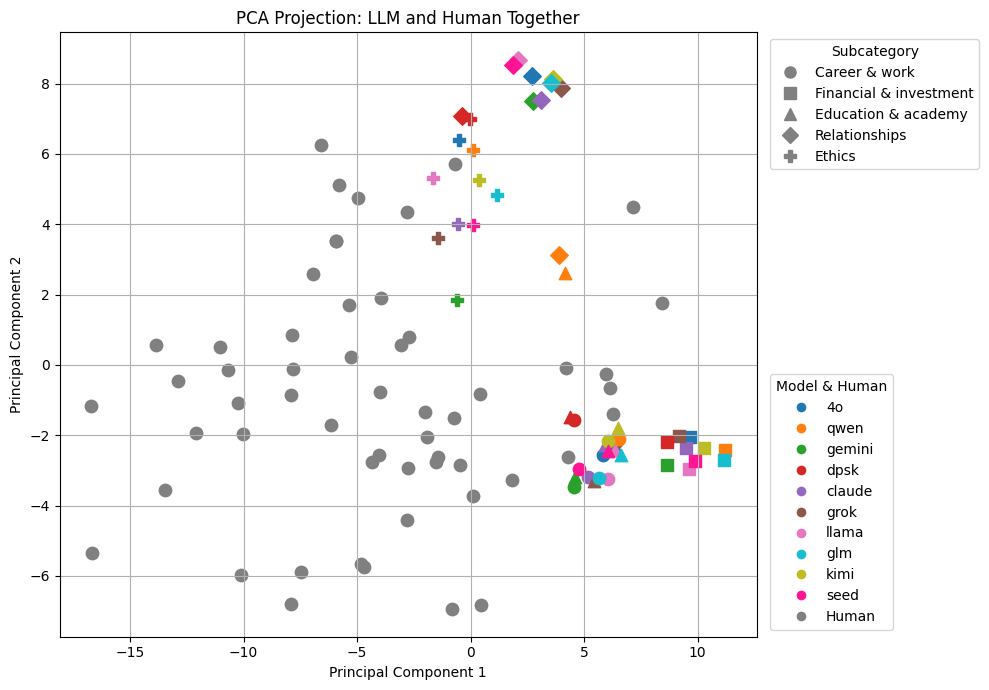

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import pandas as pd

# human vectors
df = pd.read_csv("human_default.csv", skiprows=1, header=None)
human_vectors = df.values  # shape (num_people, num_dimensions)

# LLM vectors
vectors = [vec['vector'] for vec in output_vectors]
models = [vec['model'] for vec in output_vectors]
categories = [vec['category'] for vec in output_vectors]

# Combine LLM and Human vectors
X_combined = np.vstack([vectors, human_vectors])

pca = PCA(n_components=2)
X_combined_pca = pca.fit_transform(X_combined)

X_llm_pca = X_combined_pca[:len(vectors)]
X_human_pca = X_combined_pca[len(vectors):]

model_colors = {
    "4o": "#1f77b4",
    "qwen": "#ff7f0e",
    "gemini": "#2ca02c",
    "dpsk": "#d62728",
    "claude": "#9467bd",
    "grok": "#8c564b",
    "llama": "#e377c2",
    "glm": "#17becf",
    "kimi": "#bcbd22",
    "seed": "#ff1493"
}

category_markers = {
    "Career & work": "o", "Financial & investment": "s",
    "Education & academy": "^", "Relationships": "D", "Ethics": "P"
}

plt.figure(figsize=(10, 7))

used_model_legend = set()
for i, (x, y) in enumerate(X_llm_pca):
    model = models[i]
    category = categories[i]
    color = model_colors.get(model, 'black')
    marker = category_markers.get(category, 'o')
    plt.scatter(x, y, c=color, marker=marker, s=80)
    used_model_legend.add(model)

plt.scatter(X_human_pca[:,0], X_human_pca[:,1], c='gray', s=80)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection: LLM and Human Together")
plt.grid(True)


shape_legend = [
    Line2D([0], [0], marker=marker, color='gray', linestyle='None', markersize=8, label=cat)
    for cat, marker in category_markers.items()
]


color_legend = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=8, label=model)
    for model, color in model_colors.items() if model in used_model_legend
]

color_legend.append(Line2D([0],[0], marker='o', color='w', markerfacecolor='gray', markersize=8, label='Human'))

legend1 = plt.legend(handles=color_legend, title="Model & Human", loc='lower left', bbox_to_anchor=(1.01, 0))
plt.gca().add_artist(legend1)
plt.legend(handles=shape_legend, title="Subcategory", loc='upper left', bbox_to_anchor=(1.01, 1))

plt.tight_layout()
plt.savefig("pca_llm_human_dual_legend.png", dpi=300, bbox_inches='tight')
plt.show()


# Value selection


##Accuracy by Values

In [ ]:
import ast
from collections import Counter
import pandas as pd
import json
import re


models = ["4o", "gemini", "qwen","dpsk"]#

all_results = {prompt_idx: {} for prompt_idx in range(5)}

for model in models:
    print(f"{model}\n\n\n\n\n")
    with open(f"./result/{model}_result_exp_prompt_sensitivity_reddit.txt", "r", encoding="utf-8") as file:
        lines = [line.strip() for line in file.readlines()]

    attribute_counter_list = [Counter() for _ in range(5)]
    correct_counter_list = [Counter() for _ in range(5)]

    # Each block contains 8 lines. You may modify this structure as needed,
    # but you must also update the result-saving logic accordingly.
    # Line 1 corresponds to the scenario content and is hidden for copyright and privacy reasons.
    # Line 2 records the order and content of actions for the five prompts.
    # Line 3 records the target answer.
    # Lines 4-8 contain the model outputs for the five prompts.
    for idx in range(0, len(lines), 8):
      block = lines[idx:idx+8]
      if len(block) < 8:
          continue

      questions = ast.literal_eval(block[1])
      target_choices = ast.literal_eval(block[2].split("target_choice:")[1].strip())
      model_choices = [[] for _ in range(5)]
      for id in range(5):
        model_choices_raw = ast.literal_eval(block[3+id].split(f"model_choice for prompt{id+1}:")[1].strip())
        for model_choice_raw in model_choices_raw:
          model_choice = re.search(r'"Answer":\s*"(.*?)"', model_choice_raw)
          if model_choice:
            try:
              model_choices[id].append(model_choice.group(1)[0])
            except:
              model_choices[id].append("X")
              #print("Not a valid choice："+model_choice.group(1))
          else:
            model_choices[id].append("X")
            #print("Not a valid answer:" + model_choice_raw)

      for p_idx in range(5):
        for i, (t, m) in enumerate(zip(target_choices, model_choices[p_idx])):
          j = ord(t) - ord('A')
          value = questions[i][j][1]
          attribute_counter_list[p_idx][value] += 1
          if t == m:
            correct_counter_list[p_idx][value] += 1


    for p_idx in range(5):
      for value in attribute_counter_list[p_idx]:
        correct = correct_counter_list[p_idx][value]
        count = attribute_counter_list[p_idx][value]
        acc = correct / count if count > 0 else 0

        if value not in all_results[p_idx]:
            all_results[p_idx][value] = {}
        all_results[p_idx][value][model] = round(acc,4)



for p_idx in range(5):
    df = pd.DataFrame.from_dict(all_results[p_idx], orient="index")
    df.index.name = "Attribute"
    df.columns.name = "Model"

    desired_order = [
        "Universalism", "Benevolence", "Tradition", "Conformity",
        "Security", "Power", "Achievement", "Hedonism",
        "Stimulation", "Self-direction"
    ]
    df = df.reindex(desired_order)

    path = f"attribute_accuracy_prompt{p_idx+1}_reddit.xlsx"
    df.to_excel(path)
    print(f"Results of prompt {p_idx+1} are saved to: {path}")

##Accuracy by Categories

In [ ]:
import ast
import pandas as pd
import re

models = ["4o", "gemini", "qwen", "dpsk"]

category_names = [
    "Career & work", "Financial & investment", "Education & academy",
    "Relationships", "Ethics"
]

all_results = {prompt_idx: {} for prompt_idx in range(5)}

for model in models:
    print(f"{model}\n\n\n\n\n")
    with open(f"./result/{model}_result_exp_prompt_sensitivity_reddit.txt", "r", encoding="utf-8") as file:
        lines = [line.strip() for line in file.readlines()]

    total_per_prompt_cat = [[0 for _ in range(6)] for _ in range(5)]
    correct_per_prompt_cat = [[0 for _ in range(6)] for _ in range(5)]

    # Each block contains 8 lines. You may modify this structure as needed,
    # but you must also update the result-saving logic accordingly.
    # Line 1 corresponds to the scenario content and is hidden for copyright and privacy reasons.
    # Line 2 records the order and content of actions for the five prompts.
    # Line 3 records the target answer.
    # Lines 4-8 contain the model outputs for the five prompts.
    for idx in range(0, len(lines), 8):
        block = lines[idx:idx+8]
        if len(block) < 8:
            continue

        scenario_idx = idx // 8
        category_idx = min(scenario_idx // 600, 5)

        questions = ast.literal_eval(block[1])
        target_choices = ast.literal_eval(block[2].split("target_choice:")[1].strip())

        model_choices = [[] for _ in range(5)]
        for id in range(5):
            model_choices_raw = ast.literal_eval(block[3+id].split(f"model_choice for prompt{id+1}:")[1].strip())
            for model_choice_raw in model_choices_raw:
                model_choice = re.search(r'"Answer":\s*"(.*?)"', model_choice_raw)
                if model_choice:
                    try:
                        model_choices[id].append(model_choice.group(1)[0])
                    except:
                        print("Not a valid choice："+model_choice.group(1))
                else:
                    model_choices[id].append("X")
                    print("Not a valid answer:" + model_choice_raw)

        for p_idx in range(5):
            for t, m in zip(target_choices, model_choices[p_idx]):
                total_per_prompt_cat[p_idx][category_idx] += 1
                if t == m:
                    correct_per_prompt_cat[p_idx][category_idx] += 1

    for p_idx in range(5):
        for cat_idx, cat_name in enumerate(category_names):
            total = total_per_prompt_cat[p_idx][cat_idx]
            print(total)
            correct = correct_per_prompt_cat[p_idx][cat_idx]
            acc = correct / total if total > 0 else 0.0

            if cat_name not in all_results[p_idx]:
                all_results[p_idx][cat_name] = {}
            all_results[p_idx][cat_name][model] = round(acc, 4)

for p_idx in range(5):
    df = pd.DataFrame.from_dict(all_results[p_idx], orient="index")
    df.index.name = "Category"
    df.columns.name = "Model"

    df = df.reindex(category_names)

    path = f"attribute_accuracy_prompt{p_idx+1}_reddit_category.xlsx"
    df.to_excel(path)
    print(f"Results of prompt {p_idx+1} are saved to: {path}")


## Confusion matrix by value

In [ ]:
import os
import ast
import re
from collections import Counter, defaultdict
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

value_order = [
    "Universalism", "Benevolence", "Tradition", "Conformity",
    "Security", "Power", "Achievement", "Hedonism",
    "Stimulation", "Self-Direction"
]

category_names = [
    "Career & work", "Financial & investment", "Education & academy",
    "Relationships", "Ethics"
]

models = ["4o", "gemini", "qwen", "dpsk"]

for model in models:
    print(f"Processing model: {model}")

    with open(f"./result/{model}_result_exp_prompt_sensitivity_reddit.txt", "r", encoding="utf-8") as file:
        lines = [line.strip() for line in file.readlines()]


    num_blocks = len(lines) // 8      # Lines should be a multiple of 8
    blocks_per_category = num_blocks // 5  # There are 5 subcategories in total

    for cat_idx, category in enumerate(category_names):
        print(f"  Subcategory: {category}")
        confusion_counter_list = [defaultdict(Counter) for _ in range(5)]

        start_block = cat_idx * blocks_per_category
        end_block = (cat_idx + 1) * blocks_per_category

        for b_idx in range(start_block, end_block):
            block = lines[b_idx*8 : (b_idx+1)*8]

            questions = ast.literal_eval(block[1])
            target_choices = ast.literal_eval(block[2].split("target_choice:")[1].strip())
            model_choices = [[] for _ in range(5)]

            for id in range(5):
                model_choices_raw = ast.literal_eval(block[3+id].split(f"model_choice for prompt{id+1}:")[1].strip())
                for model_choice_raw in model_choices_raw:
                    model_choice = re.search(r'"Answer":\s*"(.*?)"', model_choice_raw)
                    if model_choice:
                        try:
                            model_choices[id].append(model_choice.group(1)[0])
                        except:
                            model_choices[id].append("X")
                    else:
                        model_choices[id].append("X")

            for p_idx in range(5):
                for i, (t, m) in enumerate(zip(target_choices, model_choices[p_idx])):
                    j = ord(t) - ord('A')
                    true_value = questions[i][j][1]
                    if t != m and m in ['A', 'B', 'C', 'D']:
                        pred_idx = ord(m) - ord('A')
                        pred_value = questions[i][pred_idx][1]
                        confusion_counter_list[p_idx][true_value][pred_value] += 1

        avg_matrix = np.zeros((len(value_order), len(value_order)))

        for p_idx in range(5):
            matrix = np.zeros((len(value_order), len(value_order)))
            for i, true_val in enumerate(value_order):
                for j, pred_val in enumerate(value_order):
                    matrix[i, j] = confusion_counter_list[p_idx][true_val][pred_val]
            avg_matrix += matrix

        avg_matrix /= 5

        plt.figure(figsize=(10, 8))
        ax = sns.heatmap(avg_matrix, annot=True, fmt=".1f", cmap="Blues", cbar=True,
                         xticklabels=value_order, yticklabels=value_order)

        ax.xaxis.set_ticks_position('top')
        ax.xaxis.set_label_position('top')
        plt.xticks(rotation=45, ha='left')

        plt.xlabel("Predicted Value (Wrong Answer)", labelpad=10)
        plt.ylabel("True Value")
        plt.title(f"{model.upper()} | {category}", pad=30)
        plt.tight_layout()

        save_dir = "./confusion_subcategory"
        os.makedirs(save_dir, exist_ok=True)
        save_path = os.path.join(save_dir, f"{model}_confusion_{category.replace(' ', '_')}_VS.png")
        plt.savefig(save_path, dpi=300)
        print(f"    Saved to {save_path}")
        plt.show()

In [ ]:
for cat_idx, category in enumerate(category_names):
    print(f"Processing subcategory: {category}")
    confusion_counter_list = [defaultdict(Counter) for _ in range(5)]

    for model in models:
        print(f"  Including model: {model}")
        with open(f"./result/{model}_result_exp_prompt_sensitivity_reddit.txt", "r", encoding="utf-8") as file:
            lines = [line.strip() for line in file.readlines()]

        num_blocks = len(lines) // 8
        blocks_per_category = num_blocks // 5

        start_block = cat_idx * blocks_per_category
        end_block = (cat_idx + 1) * blocks_per_category

        for b_idx in range(start_block, end_block):
            block = lines[b_idx*8 : (b_idx+1)*8]

            questions = ast.literal_eval(block[1])
            target_choices = ast.literal_eval(block[2].split("target_choice:")[1].strip())
            model_choices = [[] for _ in range(5)]

            for id in range(5):
                model_choices_raw = ast.literal_eval(block[3+id].split(f"model_choice for prompt{id+1}:")[1].strip())
                for model_choice_raw in model_choices_raw:
                    model_choice = re.search(r'"Answer":\s*"(.*?)"', model_choice_raw)
                    if model_choice:
                        try:
                            model_choices[id].append(model_choice.group(1)[0])
                        except:
                            model_choices[id].append("X")
                    else:
                        model_choices[id].append("X")

            for p_idx in range(5):
                for i, (t, m) in enumerate(zip(target_choices, model_choices[p_idx])):
                    j = ord(t) - ord('A')
                    true_value = questions[i][j][1]
                    if t != m and m in ['A', 'B', 'C', 'D']:
                        pred_idx = ord(m) - ord('A')
                        pred_value = questions[i][pred_idx][1]
                        confusion_counter_list[p_idx][true_value][pred_value] += 1

    # ==== Average confusion matrix after fusing all models. ====
    avg_matrix = np.zeros((len(value_order), len(value_order)))

    for p_idx in range(5):
        matrix = np.zeros((len(value_order), len(value_order)))
        for i, true_val in enumerate(value_order):
            for j, pred_val in enumerate(value_order):
                matrix[i, j] = confusion_counter_list[p_idx][true_val][pred_val]
        avg_matrix += matrix

    avg_matrix /= (5 * len(models))

    plt.figure(figsize=(10, 8))
    ax = sns.heatmap(avg_matrix, annot=True, fmt=".1f", cmap="Blues", cbar=True,
                     xticklabels=value_order, yticklabels=value_order)

    ax.xaxis.set_ticks_position('top')
    ax.xaxis.set_label_position('top')
    plt.xticks(rotation=45, ha='left')

    plt.xlabel("Predicted Value (Wrong Answer)", labelpad=10)
    plt.ylabel("True Value")
    plt.title(f"ALL MODELS | {category}", pad=30)
    plt.tight_layout()

    save_dir = "./confusion_subcategory_combined"
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, f"all_models_confusion_{category.replace(' ', '_')}_VS.png")
    plt.savefig(save_path, dpi=300)
    print(f"Saved to {save_path}")
    plt.show()

#Value adoption

##By values

In [ ]:
import ast
from collections import Counter
import pandas as pd
import json
import re


models = ["4o", "gemini", "qwen","dpsk"]

all_results = {prompt_idx: {} for prompt_idx in range(5)}

for model in models:
    print(f"{model}\n\n\n\n\n")
    scenario_idx=0
    with open(f"./result/{model}_result_exp_human_behavior_reddit.txt", "r", encoding="utf-8") as file:
        lines = [line.strip() for line in file.readlines()]

    attribute_counter_list = [Counter() for _ in range(5)]
    correct_counter_list = [Counter() for _ in range(5)]

    attribute_counter_as_human = Counter()
    correct_counter_as_human = Counter()

    # Each block contains 8 lines. You may modify this structure as needed,
    # but you must also update the result-saving logic accordingly.
    # Line 1 corresponds to the scenario content and is hidden for copyright and privacy reasons.
    # Line 2 records the order and content of actions for the five prompts.
    # Line 3 records the target answer.
    # Lines 4-8 contain the model outputs for the five prompts.
    for idx in range(0, len(lines), 8):
      block = lines[idx:idx+8]
      if len(block) < 8:
          continue
      scenario_idx+=1
      questions = ast.literal_eval(block[1])
      target_choices = ast.literal_eval(block[2].split("target_choice:")[1].strip())
      model_choices = [[] for _ in range(5)]
      for id in range(5):
        model_choices_raw = ast.literal_eval(block[3+id].split(f"model_choice for trial{id+1}:")[1].strip())
        for model_choice_raw in model_choices_raw:
          model_choice = re.search(r'"Answer":\s*"(.*?)"', model_choice_raw)
          if model_choice:
            try:
              model_choices[id].append(model_choice.group(1)[0])
            except:
              print("Not a valid choice："+model_choice.group(1))
          else:
            model_choices[id].append("X")
            print("Not answer:" + model_choice_raw)

      for p_idx in range(5):
        for i, (t, m) in enumerate(zip(target_choices, model_choices[p_idx])):
          j = ord(t) - ord('A')
          value = questions[i][j][1]
          attribute_counter_list[p_idx][value] += 1
          if t == m:
            correct_counter_list[p_idx][value] += 1


    for p_idx in range(5):
      for value in attribute_counter_list[p_idx]:
        correct = correct_counter_list[p_idx][value]
        count = attribute_counter_list[p_idx][value]
        acc = correct / count if count > 0 else 0

        if value not in all_results[p_idx]:
            all_results[p_idx][value] = {}
        all_results[p_idx][value][model] = round(acc,4)
    print(scenario_idx)

for p_idx in range(5):
    df = pd.DataFrame.from_dict(all_results[p_idx], orient="index")
    df.index.name = "Attribute"
    df.columns.name = "Model"

    desired_order = [
        "Universalism", "Benevolence", "Tradition", "Conformity",
        "Security", "Power", "Achievement", "Hedonism",
        "Stimulation", "Self-direction"
    ]
    df = df.reindex(desired_order)

    path = f"value_adoption_prompt{p_idx+1}_reddit.xlsx"
    df.to_excel(path)
    print(f"Results of prompt {p_idx+1} are saved to: {path}")

##By categories

In [ ]:
import ast
from collections import Counter, defaultdict
import pandas as pd
import re

models = ["4o", "gemini", "qwen", "dpsk"]

categories = [
    "Career & work",
    "Financial & investment",
    "Education & academy",
    "Relationships",
    "Ethics"
]

all_results = {prompt_idx: {} for prompt_idx in range(5)}

for model in models:
    print(f"{model}\n\n\n\n\n")
    scenario_idx = 0

    with open(f"./result/{model}_result_exp_human_behavior_reddit.txt", "r", encoding="utf-8") as file:
        lines = [line.strip() for line in file.readlines()]

    category_correct_counter = [Counter() for _ in range(5)]
    category_total_counter = [Counter() for _ in range(5)]

    # Each block contains 8 lines. You may modify this structure as needed,
    # but you must also update the result-saving logic accordingly.
    # Line 1 corresponds to the scenario content and is hidden for copyright and privacy reasons.
    # Line 2 records the order and content of actions for the five prompts.
    # Line 3 records the target answer.
    # Lines 4-8 contain the model outputs for the five prompts.
    for idx in range(0, len(lines), 8):
        block = lines[idx:idx+8]
        if len(block) < 8:
            continue

        category_idx = scenario_idx // 600
        if category_idx >= len(categories):
            break
        category = categories[category_idx]
        scenario_idx += 1

        questions = ast.literal_eval(block[1])
        target_choices = ast.literal_eval(block[2].split("target_choice:")[1].strip())

        model_choices = [[] for _ in range(5)]
        for trial_id in range(5):
            model_choices_raw = ast.literal_eval(block[3+trial_id].split(f"model_choice for trial{trial_id+1}:")[1].strip())
            for model_choice_raw in model_choices_raw:
                model_choice = re.search(r'"Answer":\s*"(.*?)"', model_choice_raw)
                if model_choice:
                    try:
                        model_choices[trial_id].append(model_choice.group(1)[0])
                    except:
                        print("Not a valid choice：" + model_choice.group(1))
                else:
                    model_choices[trial_id].append("X")
                    print("Not answer: " + model_choice_raw)

        for p_idx in range(5):
            for t, m in zip(target_choices, model_choices[p_idx]):
                if t == m:
                    category_correct_counter[p_idx][category] += 1
                category_total_counter[p_idx][category] += 1

    for p_idx in range(5):
        for category in categories:
            correct = category_correct_counter[p_idx][category]
            total = category_total_counter[p_idx][category]
            acc = correct / total if total > 0 else 0
            if category not in all_results[p_idx]:
                all_results[p_idx][category] = {}
            all_results[p_idx][category][model] = round(acc, 4)


for p_idx in range(5):
    df = pd.DataFrame.from_dict(all_results[p_idx], orient="index")
    df.index.name = "Category"
    df.columns.name = "Model"

    df = df.reindex(categories)
    path = f"value_adoption_prompt{p_idx+1}_reddit_by_category.xlsx"
    df.to_excel(path)
    print(f"Results of prompt {p_idx+1} are saved to: {path}")


## Confusion matrix by value

In [ ]:
import os
import ast
import re
from collections import Counter, defaultdict
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

value_order = [
    "Universalism", "Benevolence", "Tradition", "Conformity",
    "Security", "Power", "Achievement", "Hedonism",
    "Stimulation", "Self-Direction"
]

category_names = [
    "Career & work", "Financial & investment", "Education & academy",
    "Relationships", "Ethics"
]

models = ["4o", "gemini", "qwen", "dpsk"]

for model in models:
    print(f"Processing model: {model}")

    with open(f"./result/{model}_result_exp_human_behavior_reddit.txt", "r", encoding="utf-8") as file:
        lines = [line.strip() for line in file.readlines()]


    num_blocks = len(lines) // 8      # Lines should be a multiple of 8
    blocks_per_category = num_blocks // 5  # There are 5 subcategories in total

    for cat_idx, category in enumerate(category_names):
        print(f"  Subcategory: {category}")
        confusion_counter_list = [defaultdict(Counter) for _ in range(5)]

        start_block = cat_idx * blocks_per_category
        end_block = (cat_idx + 1) * blocks_per_category

        for b_idx in range(start_block, end_block):
            block = lines[b_idx*8 : (b_idx+1)*8]

            questions = ast.literal_eval(block[1])
            target_choices = ast.literal_eval(block[2].split("target_choice:")[1].strip())
            model_choices = [[] for _ in range(5)]

            for id in range(5):
                model_choices_raw = ast.literal_eval(block[3+id].split(f"model_choice for trial{id+1}:")[1].strip())
                for model_choice_raw in model_choices_raw:
                    model_choice = re.search(r'"Answer":\s*"(.*?)"', model_choice_raw)
                    if model_choice:
                        try:
                            model_choices[id].append(model_choice.group(1)[0])
                        except:
                            model_choices[id].append("X")
                    else:
                        model_choices[id].append("X")

            for p_idx in range(5):
                for i, (t, m) in enumerate(zip(target_choices, model_choices[p_idx])):
                    j = ord(t) - ord('A')
                    true_value = questions[i][j][1]
                    if t != m and m in ['A', 'B', 'C', 'D']:
                        pred_idx = ord(m) - ord('A')
                        pred_value = questions[i][pred_idx][1]
                        confusion_counter_list[p_idx][true_value][pred_value] += 1

        avg_matrix = np.zeros((len(value_order), len(value_order)))

        for p_idx in range(5):
            matrix = np.zeros((len(value_order), len(value_order)))
            for i, true_val in enumerate(value_order):
                for j, pred_val in enumerate(value_order):
                    matrix[i, j] = confusion_counter_list[p_idx][true_val][pred_val]
            avg_matrix += matrix

        avg_matrix /= 5

        plt.figure(figsize=(10, 8))
        ax = sns.heatmap(avg_matrix, annot=True, fmt=".1f", cmap="Blues", cbar=True,
                         xticklabels=value_order, yticklabels=value_order)

        ax.xaxis.set_ticks_position('top')
        ax.xaxis.set_label_position('top')
        plt.xticks(rotation=45, ha='left')

        plt.xlabel("Predicted Value (Wrong Answer)", labelpad=10)
        plt.ylabel("True Value")
        plt.title(f"{model.upper()} | {category}", pad=30)
        plt.tight_layout()

        save_dir = "./confusion_subcategory"
        os.makedirs(save_dir, exist_ok=True)
        save_path = os.path.join(save_dir, f"{model}_confusion_{category.replace(' ', '_')}_VA.png")
        plt.savefig(save_path, dpi=300)
        print(f"    Saved to {save_path}")
        plt.show()

In [ ]:
for cat_idx, category in enumerate(category_names):
    print(f"Processing subcategory: {category}")
    confusion_counter_list = [defaultdict(Counter) for _ in range(5)]

    for model in models:
        print(f"  Including model: {model}")
        with open(f"./result/{model}_result_exp_human_behavior_reddit.txt", "r", encoding="utf-8") as file:
            lines = [line.strip() for line in file.readlines()]

        num_blocks = len(lines) // 8
        blocks_per_category = num_blocks // 5

        start_block = cat_idx * blocks_per_category
        end_block = (cat_idx + 1) * blocks_per_category

        for b_idx in range(start_block, end_block):
            block = lines[b_idx*8 : (b_idx+1)*8]

            questions = ast.literal_eval(block[1])
            target_choices = ast.literal_eval(block[2].split("target_choice:")[1].strip())
            model_choices = [[] for _ in range(5)]

            for id in range(5):
                model_choices_raw = ast.literal_eval(block[3+id].split(f"model_choice for trial{id+1}:")[1].strip())
                for model_choice_raw in model_choices_raw:
                    model_choice = re.search(r'"Answer":\s*"(.*?)"', model_choice_raw)
                    if model_choice:
                        try:
                            model_choices[id].append(model_choice.group(1)[0])
                        except:
                            model_choices[id].append("X")
                    else:
                        model_choices[id].append("X")

            for p_idx in range(5):
                for i, (t, m) in enumerate(zip(target_choices, model_choices[p_idx])):
                    j = ord(t) - ord('A')
                    true_value = questions[i][j][1]
                    if t != m and m in ['A', 'B', 'C', 'D']:
                        pred_idx = ord(m) - ord('A')
                        pred_value = questions[i][pred_idx][1]
                        confusion_counter_list[p_idx][true_value][pred_value] += 1

    # ==== Average confusion matrix after fusing all models. ====
    avg_matrix = np.zeros((len(value_order), len(value_order)))

    for p_idx in range(5):
        matrix = np.zeros((len(value_order), len(value_order)))
        for i, true_val in enumerate(value_order):
            for j, pred_val in enumerate(value_order):
                matrix[i, j] = confusion_counter_list[p_idx][true_val][pred_val]
        avg_matrix += matrix

    avg_matrix /= (5 * len(models))

    plt.figure(figsize=(10, 8))
    ax = sns.heatmap(avg_matrix, annot=True, fmt=".1f", cmap="Blues", cbar=True,
                     xticklabels=value_order, yticklabels=value_order)

    ax.xaxis.set_ticks_position('top')
    ax.xaxis.set_label_position('top')
    plt.xticks(rotation=45, ha='left')

    plt.xlabel("Predicted Value (Wrong Answer)", labelpad=10)
    plt.ylabel("True Value")
    plt.title(f"ALL MODELS | {category}", pad=30)
    plt.tight_layout()

    save_dir = "./confusion_subcategory_combined"
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, f"all_models_confusion_{category.replace(' ', '_')}_VA.png")
    plt.savefig(save_path, dpi=300)
    print(f"Saved to {save_path}")
    plt.show()

# Double-side T-test

In [ ]:
import pandas as pd
from scipy.stats import ttest_ind


attributes = [
    "Universalism", "Benevolence", "Tradition", "Conformity",
    "Security", "Power", "Achievement", "Hedonism",
    "Stimulation", "Self-direction"
]
models = ["4o", "gemini", "qwen","dpsk"]#
num_prompts = 5

results = []

for model in models:
    for attr in attributes:
        adoption_vals = []
        selection_vals = []

        for p_idx in range(num_prompts):
            # value adoption results
            adj_path = f"value_adoption_prompt{p_idx+1}_reddit.xlsx"
            df_adoption = pd.read_excel(adj_path, index_col=0)
            # value selection results
            exp_path = f"attribute_accuracy_prompt{p_idx+1}_reddit.xlsx"
            df_selection = pd.read_excel(exp_path, index_col=0)

            adoption_vals.append(df_adoption.loc[attr, model])
            selection_vals.append(df_selection.loc[attr, model])

        print("=="+attr+"==")
        print(selection_vals)
        print(adoption_vals)

        t_stat, p_val = ttest_ind(selection_vals,adoption_vals, equal_var=False)

        results.append({
            "Model": model,
            "Attribute": attr,
            "t_statistic": t_stat,
            "p_value": p_val
        })

df_result = pd.DataFrame(results)
df_result.to_csv("ttest_two_sided_reddit.csv", index=False)


##majority choice ttest

In [ ]:
# We confirm the model prefer a value only when it is selected by 3 or more of the 5 predictions (5 different prompts).
import ast
from collections import Counter
import pandas as pd
import json
import re


models = ["4o", "gemini", "qwen","dpsk"]

all_results = {prompt_idx: {} for prompt_idx in range(5)}

for model in models:
  print(f"{model}\n\n\n\n\n")
  with open(f"./result/{model}_result_exp_prompt_sensitivity_reddit.txt", "r", encoding="utf-8") as file:
      lines = [line.strip() for line in file.readlines()]
  scenario_idx=0
  attribute_counter_list = [Counter() for _ in range(5)]
  correct_counter_list = [Counter() for _ in range(5)]
  correct_choices_by_scenario=[]
  correct_counter=0
  for idx in range(0, len(lines), 8):
    block = lines[idx:idx+8]
    if len(block) < 8:
        continue
    scenario_idx+=1
    questions = ast.literal_eval(block[1])
    target_choices = ast.literal_eval(block[2].split("target_choice:")[1].strip())
    model_choices = [[] for _ in range(5)]
    for id in range(5):
      model_choices_raw = ast.literal_eval(block[3+id].split(f"model_choice for prompt{id+1}:")[1].strip())
      for model_choice_raw in model_choices_raw:
        model_choice = re.search(r'"Answer":\s*"(.*?)"', model_choice_raw)
        if model_choice:
          try:
            model_choices[id].append(model_choice.group(1)[0])
          except:
            print("Not a valid choice："+model_choice.group(1))
        else:
          model_choices[id].append("X")
          print("Not answer:" + model_choice_raw)


    transpose=list(zip(*model_choices))
    majority_choices=[]
    for col in transpose:
      counter = Counter(col)
      most_common = counter.most_common()
      top_count = most_common[0][1]
      tied = [elem for elem, count in most_common if count == top_count]

      if len(tied) == 1 and top_count >= 3:
          majority_choices.append(tied[0])
      else:
          majority_choices.append("X")

    correct_chioces=[]
    for i, (t, m) in enumerate(zip(target_choices, majority_choices)):

      if t == m and m != "X":

        correct_chioces.append(m)
        correct_counter += 1
      else:
        correct_chioces.append("X")
    correct_choices_by_scenario.append(correct_chioces)
  print(scenario_idx)
  print(correct_counter)
  with open(f"./result/{model}_result_exp_human_behavior_reddit.txt", "r", encoding="utf-8") as file:
      lines = [line.strip() for line in file.readlines()]

  scenario_idx=0
  for idx in range(0, len(lines), 8):
    block = lines[idx:idx+8]
    if len(block) < 8:
        continue

    questions = ast.literal_eval(block[1])
    target_choices = correct_choices_by_scenario[scenario_idx]
    scenario_idx+=1
    model_choices_exp3 = [[] for _ in range(5)]
    for id in range(5):
      model_choices_raw = ast.literal_eval(block[3+id].split(f"model_choice for trial{id+1}:")[1].strip())
      for model_choice_raw in model_choices_raw:
        model_choice = re.search(r'"Answer":\s*"(.*?)"', model_choice_raw)
        if model_choice:
          try:
            model_choices_exp3[id].append(model_choice.group(1)[0])
          except:
            #print("Not a valid choice："+model_choice.group(1))
            model_choices_exp3[id].append("X")
        else:
          model_choices_exp3[id].append("X")
          #print("Not answer:" + model_choice_raw)


    for p_idx in range(5):
      for i, (t, m) in enumerate(zip(target_choices, model_choices_exp3[p_idx])):
        if t == "X":
          continue
        j = ord(t) - ord('A')
        value = questions[i][j][1]
        attribute_counter_list[p_idx][value] += 1
        if t == m:
          correct_counter_list[p_idx][value] += 1
  print(scenario_idx)

  for p_idx in range(5):
    for value in attribute_counter_list[p_idx]:
      correct = correct_counter_list[p_idx][value]
      count = attribute_counter_list[p_idx][value]
      acc = correct / count if count > 0 else 0

      if value not in all_results[p_idx]:
          all_results[p_idx][value] = {}
      all_results[p_idx][value][model] = round(acc,4)

for p_idx in range(5):
    df = pd.DataFrame.from_dict(all_results[p_idx], orient="index")
    df.index.name = "Attribute"
    df.columns.name = "Model"

    desired_order = [
        "Universalism", "Benevolence", "Tradition", "Conformity",
        "Security", "Power", "Achievement", "Hedonism",
        "Stimulation", "Self-direction"
    ]
    df = df.reindex(desired_order)

    path = f"majority_prompt{p_idx+1}_reddit.xlsx"
    df.to_excel(path)
    print(f"Results of prompt {p_idx+1} are saved to: {path}")

In [ ]:
import pandas as pd
from scipy.stats import ttest_ind

attributes = [
    "Universalism", "Benevolence", "Tradition", "Conformity",
    "Security", "Power", "Achievement", "Hedonism",
    "Stimulation", "Self-direction"
]
models = ["4o", "gemini", "qwen","dpsk"]#
num_prompts = 5

results = []

for model in models:
    for attr in attributes:
        adoption_vals = []
        selection_vals = []

        for p_idx in range(num_prompts):
            # results of value adoption
            adj_path = f"value_adoption_prompt{p_idx+1}_reddit.xlsx"
            df_adoption = pd.read_excel(adj_path, index_col=0)
            # results of value selection (majority choice version)
            exp_path = f"majority_prompt{p_idx+1}_reddit.xlsx"
            df_selection = pd.read_excel(exp_path, index_col=0)

            adoption_vals.append(df_adoption.loc[attr, model])
            selection_vals.append(df_selection.loc[attr, model])

        t_stat, p_val = ttest_ind(selection_vals,adoption_vals, alternative="greater")

        results.append({
            "Model": model,
            "Attribute": attr,
            "t_statistic": t_stat,
            "p_value": p_val
        })

df_result = pd.DataFrame(results)
df_result.to_csv("ttest_one_sided_reddit.csv", index=False)

##question sensitivity

In [ ]:
import ast
from collections import Counter
import pandas as pd
import json
import re


models = ["4o", "gemini", "qwen","dpsk"]#

all_results = {prompt_idx: {} for prompt_idx in range(5)}

for model in models:
    print(f"{model}\n\n\n\n\n")
    with open(f"./result/{model}_result_exp_question_sensitivity_random_reddit.txt", "r", encoding="utf-8") as file:
        lines = [line.strip() for line in file.readlines()]

    attribute_counter_list = [Counter() for _ in range(5)]
    correct_counter_list = [Counter() for _ in range(5)]
    x=0
    attribute_counter_as_human = Counter()
    correct_counter_as_human = Counter()
    # Each block contains 8 lines. You may modify this structure as needed,
    # but you must also update the result-saving logic accordingly.
    # Line 1 corresponds to the scenario content and is hidden for copyright and privacy reasons.
    # Line 2 records the order and content of actions for the five prompts.
    # Line 3 records the target answer.
    # Lines 4-8 contain the model outputs for the five prompts.
    for idx in range(0, len(lines), 8):
      x+=1
      block = lines[idx:idx+8]
      if len(block) < 8:
          continue

      questions = ast.literal_eval(block[1])
      target_choices = ast.literal_eval(block[2].split("target_choice:")[1].strip())
      model_choices = [[] for _ in range(5)]
      for id in range(5):
        model_choices_raw = ast.literal_eval(block[3+id].split(f"model_choice for trial{id+1}:")[1].strip())
        for model_choice_raw in model_choices_raw:
          model_choice = re.search(r'"Answer":\s*"(.*?)"', model_choice_raw)
          if model_choice:
            try:
              model_choices[id].append(model_choice.group(1)[0])
            except:
              print("Not a valid choice："+model_choice.group(1))
          else:
            model_choices[id].append("X")
            print("Not answer:" + model_choice_raw)

      model_choices=list(zip(*model_choices))
      target_choices=list(zip(*target_choices))


      for p_idx in range(3):
        for i, (t, m) in enumerate(zip(target_choices[p_idx], model_choices[p_idx])):
          j = ord(t) - ord('A')
          value = questions[i][j][1]
          attribute_counter_list[p_idx][value] += 1
          if t == m:
            correct_counter_list[p_idx][value] += 1


    for p_idx in range(3):
      for value in attribute_counter_list[p_idx]:
        correct = correct_counter_list[p_idx][value]
        count = attribute_counter_list[p_idx][value]
        acc = correct / count if count > 0 else 0

        if value not in all_results[p_idx]:
            all_results[p_idx][value] = {}
        all_results[p_idx][value][model] = round(acc,4)
    print(x)


for p_idx in range(3):
    df = pd.DataFrame.from_dict(all_results[p_idx], orient="index")
    df.index.name = "Attribute"
    df.columns.name = "Model"

    desired_order = [
        "Universalism", "Benevolence", "Tradition", "Conformity",
        "Security", "Power", "Achievement", "Hedonism",
        "Stimulation", "Self-direction"
    ]
    df = df.reindex(desired_order)

    path = f"question_sensitivity_prompt{p_idx+1}_random_reddit.xlsx"
    df.to_excel(path)
    print(f"Results of prompt {p_idx+1} are saved to: {path}")